<a href="https://colab.research.google.com/github/PanconquesoHH/Laboratorios-ia/blob/main/LAB3_ParisHousing_basico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión lineal multivariable, polinómica y ecuación de la normal

Este cuadernillo utiliza `ParisHousing.csv` para predecir el precio de las viviendas mediante tres procedimientos: regresión lineal multivariable, regresión polinómica y ecuación de la normal. Se mantiene la lógica básica de los cuadernillos de ejemplo. En cada caso se calculan theta, el costo y las predicciones; finalmente se comparan 100 resultados.

## 1. Librerías y Google Drive

Se importan las librerías usadas en los ejemplos: NumPy para los cálculos, Pyplot para las gráficas y `PolynomialFeatures` para crear las variables polinómicas.

In [26]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from sklearn.preprocessing import PolynomialFeatures
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Carga del dataset

Las primeras 16 columnas son las características de las viviendas y la última columna (`price`) es el valor que se desea predecir. Se utilizan todos los datos, igual que en los ejemplos proporcionados.

In [27]:
# Ruta del dataset
dataset = '/content/drive/MyDrive/LAB3/ParisHousing.csv'

print(f'Archivo a usar: {os.path.abspath(dataset)}')

# Cargar el archivo CSV
df = pd.read_csv(dataset, sep=',', header=0)

# Eliminar una posible columna de índice
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Variable objetivo
y = df['price'].values

# Variables predictoras
X_df = df.drop(columns=['price']).copy()

# Convertir las variables predictoras a NumPy
X_original = X_df.values

# Número de ejemplos
m = y.size

print(f'Número de muestras: {len(y)}')
print(f'Número de características: {X_df.shape[1]}')
print(f'Tamaño de X: {X_original.shape}')
print(f'Tamaño de y: {y.shape}')
print(f'Tamaño del dataset: {df.shape}')

# Mostrar los primeros datos
display(df.head())

Archivo a usar: /content/drive/MyDrive/LAB3/ParisHousing.csv
Número de muestras: 10000
Número de características: 16
Tamaño de X: (10000, 16)
Tamaño de y: (10000,)
Tamaño del dataset: (10000, 17)


,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0


In [28]:
def plotData(x, y):
    # Grafica los puntos x e y en una figura nueva

    fig = pyplot.figure(figsize=(9, 6))

    pyplot.plot(
        x,
        y,
        'ro',
        ms=5,
        mec='k',
        alpha=0.7
    )

    pyplot.ylabel('Precio de la vivienda')
    pyplot.xlabel('Metros cuadrados')
    pyplot.title('Relación entre metros cuadrados y precio')
    pyplot.grid(alpha=0.3)

    pyplot.show()

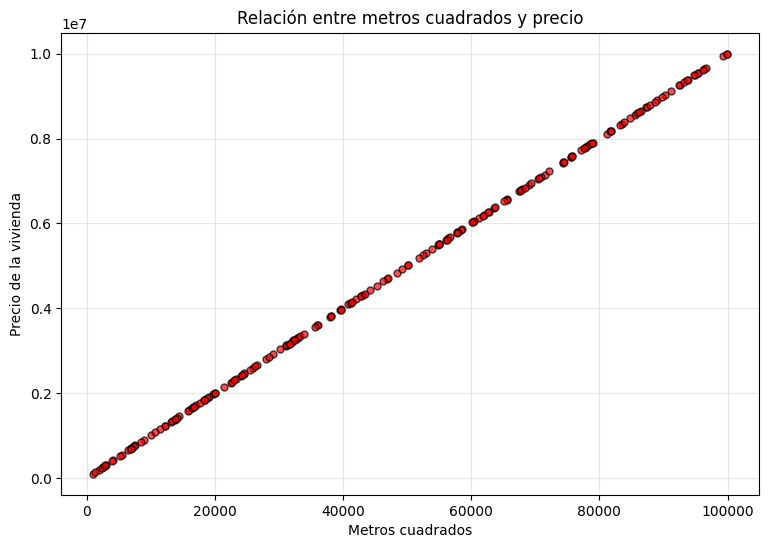

In [24]:
# Seleccionar un ejemplo cada 50 filas
indices_grafica = np.arange(0, m, 50)

plotData(
    X_original[indices_grafica, 0],
    y[indices_grafica]
)

## 3. Funciones principales

`NORMAL` coloca las características en escalas semejantes. El costo es:

$$J(\theta)=\frac{1}{2m}\sum(X\theta-y)^2$$

`gradientDescentMulti` actualiza theta en cada iteración. La estructura corresponde a la utilizada en los cuadernillos revisados.

In [3]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))
    return theta, J_history

def calcularMetricas(y, prediccion):
    mse = np.mean(np.square(prediccion - y))
    rmse = np.sqrt(mse)
    r2 = 1 - np.sum(np.square(y - prediccion)) / np.sum(np.square(y - np.mean(y)))
    return mse, rmse, r2

# 4. Regresión lineal multivariable

Se normalizan las 16 variables originales, se agrega la columna de unos para el término independiente y se calculan los parámetros mediante descenso por el gradiente.

In [4]:
X_norm_lineal, mu_lineal, sigma_lineal = featureNormalize(X_original)
X_lineal = np.concatenate([np.ones((m, 1)), X_norm_lineal], axis=1)

alpha_lineal = 0.03
num_iters_lineal = 1000
theta_lineal = np.zeros(X_lineal.shape[1])
theta_lineal, J_history_lineal = gradientDescentMulti(
    X_lineal, y, theta_lineal, alpha_lineal, num_iters_lineal)

print('Theta de la regresión lineal multivariable:')
print(theta_lineal)
print('Costo inicial:', J_history_lineal[0])
print('Costo final:', J_history_lineal[-1])

Theta de la regresión lineal multivariable:
[ 4.99344753e+06  2.87729436e+06  7.25697262e+00  1.50591974e+03
  1.48853839e+03  1.57559596e+03 -2.33169597e+01  1.36036675e+02
 -1.13041264e+00 -2.15296453e+01  7.90206420e+01  7.05980635e+01
 -6.05701175e+00 -1.30510220e+01  2.97236016e+01  9.74263091e+00
 -1.78516030e+01]
Costo inicial: 15624926715161.549
Costo final: 1798953.0964954048


### Gráfico de costo lineal

La reducción de la curva muestra cómo el error disminuye durante las iteraciones.

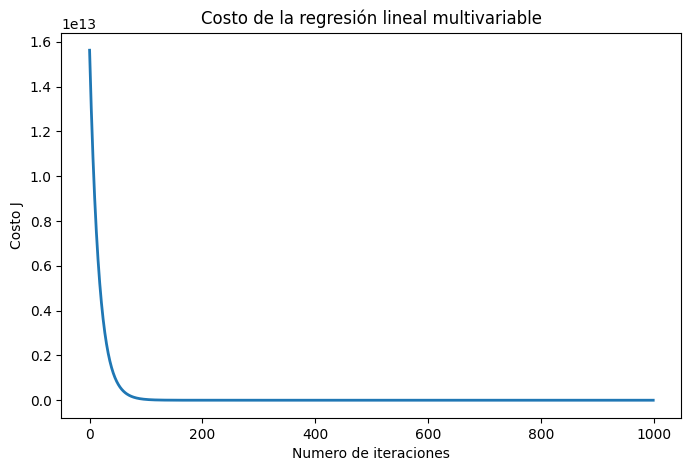

In [5]:
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history_lineal)), J_history_lineal, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Costo de la regresión lineal multivariable')
pyplot.show()

In [6]:
prediccion_lineal = np.dot(X_lineal, theta_lineal)
mse_lineal, rmse_lineal, r2_lineal = calcularMetricas(y, prediccion_lineal)
print('MSE =', mse_lineal)
print('RMSE =', rmse_lineal)
print('R2 =', r2_lineal)

MSE = 3597906.1929908097
RMSE = 1896.8147492548685
R2 = 0.9999995654042139


# 5. Regresión polinómica

`PolynomialFeatures` genera variables de grado 2: valores originales, cuadrados e interacciones. Estas características se normalizan y se utiliza la misma función de descenso por el gradiente.

In [7]:
pf = PolynomialFeatures(degree=2, include_bias=False)
X_poly_original = pf.fit_transform(X_original)
print('Forma de X original:', X_original.shape)
print('Forma de X polinómico:', X_poly_original.shape)

X_norm_poly, mu_poly, sigma_poly = featureNormalize(X_poly_original)
X_poly = np.concatenate([np.ones((m, 1)), X_norm_poly], axis=1)

alpha_poly = 0.01
num_iters_poly = 2000
theta_poly = np.zeros(X_poly.shape[1])
theta_poly, J_history_poly = gradientDescentMulti(
    X_poly, y, theta_poly, alpha_poly, num_iters_poly)

print('Theta de la regresión polinómica:')
print(theta_poly)
print('Costo inicial:', J_history_poly[0])
print('Costo final:', J_history_poly[-1])

Forma de X original: (10000, 16)
Forma de X polinómico: (10000, 152)
Theta de la regresión polinómica:
[ 4.99344752e+06  8.70180217e+05 -1.31744767e+04 -1.33488935e+04
 -9.38380644e+03 -2.08201327e+04 -2.52091264e+04 -1.78312631e+04
 -1.69090782e+04 -2.55969744e+03 -1.72616366e+04 -1.06139479e+04
 -2.63721131e+04 -2.75816008e+04 -3.59137731e+04 -1.48894653e+04
 -1.29742860e+04  3.60326466e+05  9.86289991e+04  5.75164700e+04
  4.52654564e+04  9.69919866e+04  9.44557376e+04  1.17376355e+05
  1.17838154e+05  8.69851995e+05  4.78681613e+04  4.43594584e+04
  1.14169721e+05  1.03504013e+05  1.38070851e+05  4.42922624e+04
  1.05744706e+05 -6.97051285e+03 -3.59398993e+02 -8.96385829e+02
 -7.13770451e+03  1.86806830e+03 -3.80697326e+02 -1.05415400e+04
 -1.33405045e+04 -2.48610417e+03 -1.06153870e+03 -8.46773963e+03
  3.55575833e+03 -4.78765514e+03 -9.88253122e+02 -1.46853635e+04
 -1.33488935e+04 -6.02367465e+02 -3.72188368e+03  5.01598722e+03
 -1.58855466e+03 -1.72425727e+03 -1.35892076e+04  3.

### Gráfico de costo polinómico

El gráfico permite observar el comportamiento del costo durante el cálculo de theta.

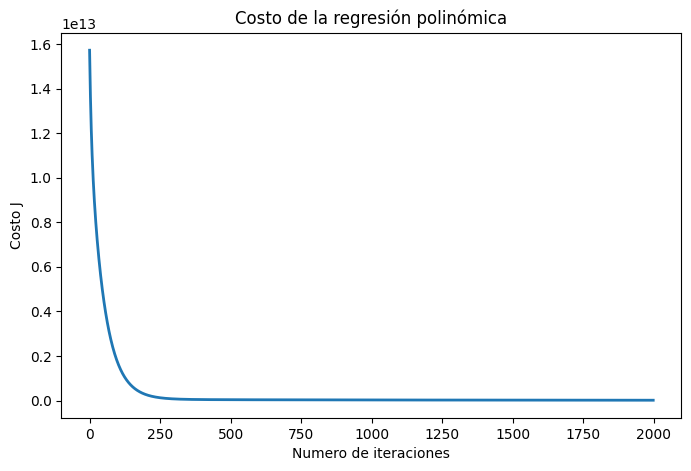

In [8]:
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Costo de la regresión polinómica')
pyplot.show()

In [9]:
prediccion_poly = np.dot(X_poly, theta_poly)
mse_poly, rmse_poly, r2_poly = calcularMetricas(y, prediccion_poly)
print('MSE =', mse_poly)
print('RMSE =', rmse_poly)
print('R2 =', r2_poly)

MSE = 26035522355.724438
RMSE = 161355.26751774928
R2 = 0.9968551352649878


# 6. Ecuación de la normal

La ecuación de la normal determina theta directamente:

$$\theta=(X^TX)^{-1}X^Ty$$

Se usa la pseudoinversa con `pinv`, que evita errores si algunas columnas están relacionadas. Este procedimiento no requiere normalización ni iteraciones.

In [10]:
def normalEqn(X, y):
    theta = np.dot(np.linalg.pinv(X), y)
    return theta

X_normal = np.concatenate([np.ones((m, 1)), X_original], axis=1)
theta_normal = normalEqn(X_normal, y)
prediccion_normal = np.dot(X_normal, theta_normal)
costo_normal = computeCostMulti(X_normal, y, theta_normal)

print('Theta calculado por la ecuación de la normal:')
print(theta_normal)
print('Costo final:', costo_normal)

Theta calculado por la ecuación de la normal:
[ 4.92675859e+03  1.00000024e+02  2.51844810e-01  3.01229551e+03
  2.97713775e+03  5.45420542e+01 -8.03888244e-04  4.73685001e+01
 -3.95730186e-01 -2.31311931e+00  1.58041540e+02  1.41196130e+02
 -2.10562533e-03 -4.50939065e-03  1.13432814e-01  1.94856126e+01
 -5.62033751e+00]
Costo final: 1798953.0964953774


### Gráfico de costo de la ecuación normal

La ecuación normal realiza un único cálculo y no produce un historial de iteraciones. Por esa razón se representa solamente el costo final obtenido.

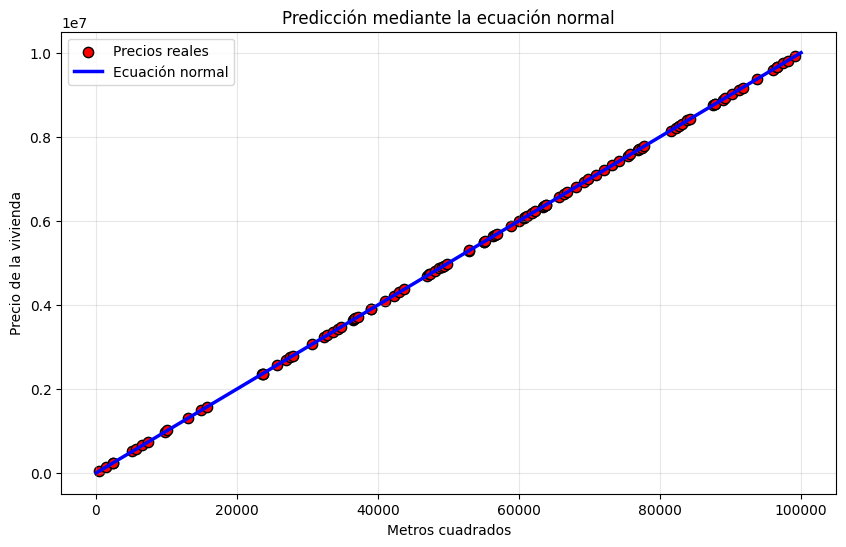

Costo final de la ecuación normal: 1798953.0964953774


In [19]:
# Seleccionar 100 viviendas distribuidas en todo el dataset
indices = np.linspace(0, m - 1, 100, dtype=int)

metros_reales = X_original[indices, 0]
precios_reales = y[indices]

# Ordenar los puntos según los metros cuadrados
orden = np.argsort(metros_reales)
metros_reales = metros_reales[orden]
precios_reales = precios_reales[orden]

# Crear 100 valores de metros cuadrados
metros_linea = np.linspace(
    X_original[:, 0].min(),
    X_original[:, 0].max(),
    100
)

# Mantener las otras características en su valor promedio
X_linea = np.tile(
    np.mean(X_original, axis=0),
    (100, 1)
)

# Modificar solamente los metros cuadrados
X_linea[:, 0] = metros_linea

# Añadir la columna de unos para theta 0
X_linea_normal = np.concatenate(
    [np.ones((100, 1)), X_linea],
    axis=1
)

# Calcular las predicciones con la ecuación normal
precios_linea_normal = np.dot(
    X_linea_normal,
    theta_normal
)

# Crear la gráfica
pyplot.figure(figsize=(10, 6))

# Precios reales
pyplot.scatter(
    metros_reales,
    precios_reales,
    color='red',
    edgecolor='black',
    s=55,
    label='Precios reales'
)

# Línea calculada con la ecuación normal
pyplot.plot(
    metros_linea,
    precios_linea_normal,
    color='blue',
    linewidth=2.5,
    label='Ecuación normal'
)

pyplot.xlabel('Metros cuadrados')
pyplot.ylabel('Precio de la vivienda')
pyplot.title('Predicción mediante la ecuación normal')
pyplot.legend()
pyplot.grid(alpha=0.3)
pyplot.show()

# Mantener visible el costo final
print('Costo final de la ecuación normal:', costo_normal)

In [12]:
mse_normal, rmse_normal, r2_normal = calcularMetricas(y, prediccion_normal)
print('MSE =', mse_normal)
print('RMSE =', rmse_normal)
print('R2 =', r2_normal)

MSE = 3597906.1929907547
RMSE = 1896.814749254854
R2 = 0.9999995654042139


# 7. Comparación de los modelos

Un RMSE menor representa un error más pequeño. Un R² más cercano a 1 indica una mejor aproximación a los precios del dataset.

In [13]:
print('{:<28s}{:>18s}{:>18s}{:>15s}'.format('Modelo', 'MSE', 'RMSE', 'R2'))
print('-' * 80)
print('{:<28s}{:>18.2f}{:>18.2f}{:>15.8f}'.format('Lineal multivariable', mse_lineal, rmse_lineal, r2_lineal))
print('{:<28s}{:>18.2f}{:>18.2f}{:>15.8f}'.format('Polinómica grado 2', mse_poly, rmse_poly, r2_poly))
print('{:<28s}{:>18.2f}{:>18.2f}{:>15.8f}'.format('Ecuación normal', mse_normal, rmse_normal, r2_normal))

Modelo                                     MSE              RMSE             R2
--------------------------------------------------------------------------------
Lineal multivariable                3597906.19           1896.81     0.99999957
Polinómica grado 2              26035522355.72         161355.27     0.99685514
Ecuación normal                     3597906.19           1896.81     0.99999957


# 8. Cien predicciones

Se comparan los precios reales de los primeros 100 ejemplos con las predicciones de los tres procedimientos.

In [14]:
print('{:>4s}{:>15s}{:>15s}{:>15s}{:>15s}'.format('Nro', 'Precio real', 'Lineal', 'Polinómica', 'Ec. normal'))
print('-' * 68)
for i in range(100):
    print('{:4d}{:15.2f}{:15.2f}{:15.2f}{:15.2f}'.format(
        i + 1, y[i], prediccion_lineal[i], prediccion_poly[i], prediccion_normal[i]))

 Nro    Precio real         Lineal     Polinómica     Ec. normal
--------------------------------------------------------------------
   1     7559081.50     7559296.86     7565151.49     7559296.86
   2     8085989.50     8089219.22     8076835.55     8089219.22
   3     5574642.10     5575672.81     5500237.08     5575672.81
   4     3232561.20     3232793.75     3316282.89     3232793.75
   5     7055052.00     7054396.58     7006438.52     7054396.58
   6     3926647.20     3927028.66     3900164.70     3927028.66
   7     5876376.50     5880682.29     5867265.80     5880682.29
   8     8696869.30     8697036.06     8889142.26     8697036.06
   9     5154055.20     5156527.05     5037088.77     5156527.05
  10     3970892.10     3970192.08     3866429.84     3970192.08
  11     2366397.30     2364909.93     2306115.14     2364909.93
  12     9652258.10     9651901.13     9923754.47     9651901.13
  13     1914688.80     1916349.09     2208449.56     1916349.09
  14     1320803.40  

### Gráfico de las 100 predicciones

Las líneas de los modelos deben mantenerse cerca de la línea de precios reales.

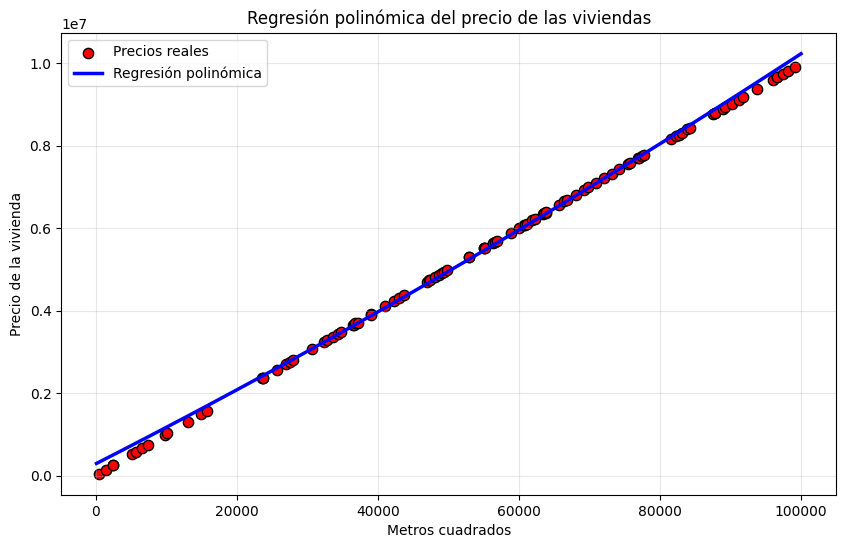

In [18]:
# Seleccionar 100 viviendas distribuidas en todo el dataset
indices = np.linspace(0, m - 1, 100, dtype=int)

metros_reales = X_original[indices, 0]
precios_reales = y[indices]

# Ordenar los puntos según los metros cuadrados
orden = np.argsort(metros_reales)
metros_reales = metros_reales[orden]
precios_reales = precios_reales[orden]

# Crear 100 valores de metros cuadrados para dibujar la curva
metros_curva = np.linspace(
    X_original[:, 0].min(),
    X_original[:, 0].max(),
    100
)

# Mantener las demás características en su valor promedio
X_curva = np.tile(
    np.mean(X_original, axis=0),
    (100, 1)
)

# Cambiar solamente los metros cuadrados
X_curva[:, 0] = metros_curva

# Aplicar la transformación polinómica
X_curva_poly = pf.transform(X_curva)

# Normalizar con la misma media y desviación
X_curva_poly = (X_curva_poly - mu_poly) / sigma_poly

# Añadir la columna de unos
X_curva_poly = np.concatenate(
    [np.ones((100, 1)), X_curva_poly],
    axis=1
)

# Calcular los precios de la curva
precios_curva = np.dot(X_curva_poly, theta_poly)

# Crear la gráfica
pyplot.figure(figsize=(10, 6))

pyplot.scatter(
    metros_reales,
    precios_reales,
    color='red',
    edgecolor='black',
    s=55,
    label='Precios reales'
)

pyplot.plot(
    metros_curva,
    precios_curva,
    color='blue',
    linewidth=2.5,
    label='Regresión polinómica'
)

pyplot.xlabel('Metros cuadrados')
pyplot.ylabel('Precio de la vivienda')
pyplot.title('Regresión polinómica del precio de las viviendas')
pyplot.legend()
pyplot.grid(alpha=0.3)
pyplot.show()

# Conclusión

Los tres procedimientos calculan theta y predicen el precio. Las curvas del descenso por el gradiente muestran la reducción del costo; la ecuación normal obtiene su resultado directamente. Las métricas y las 100 comparaciones permiten observar la efectividad alcanzada.